In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path
import sys

# Append project root to path to import config
sys.path.append(str(Path.cwd().parent))
import config
import importlib
importlib.reload(config)

<module 'config' from '/Users/meghna/Desktop/dynamic-pricing-engine/config.py'>

In [18]:
df = pd.read_csv(config.TRAIN_FILE, encoding='utf-8', encoding_errors='replace')
print(f"Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)

Shape: (148253, 8)

Data Types:
train_id               int64
name                  object
item_condition_id      int64
category_name         object
brand_name            object
price                float64
shipping               int64
item_description      object
dtype: object


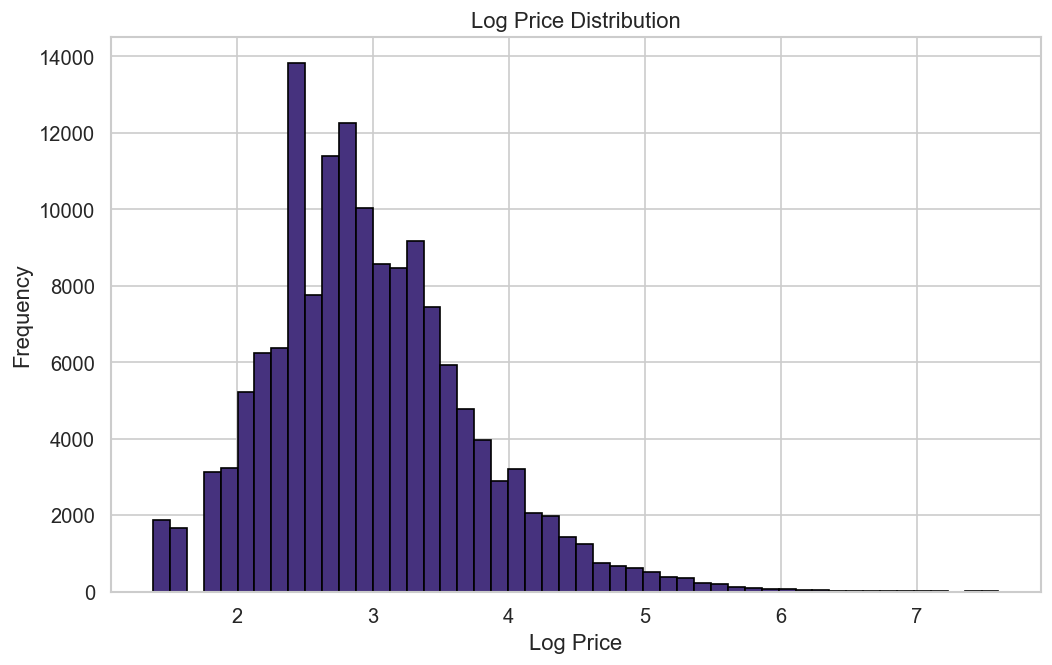

In [19]:
df_price = df[df['price'] > 0].copy()
df_price['log_price'] = np.log1p(df_price['price'])

plt.figure(figsize=(10, 6))
plt.hist(df_price['log_price'], bins=50, edgecolor='k')
plt.title('Log Price Distribution')
plt.xlabel('Log Price')
plt.ylabel('Frequency')
plt.show()

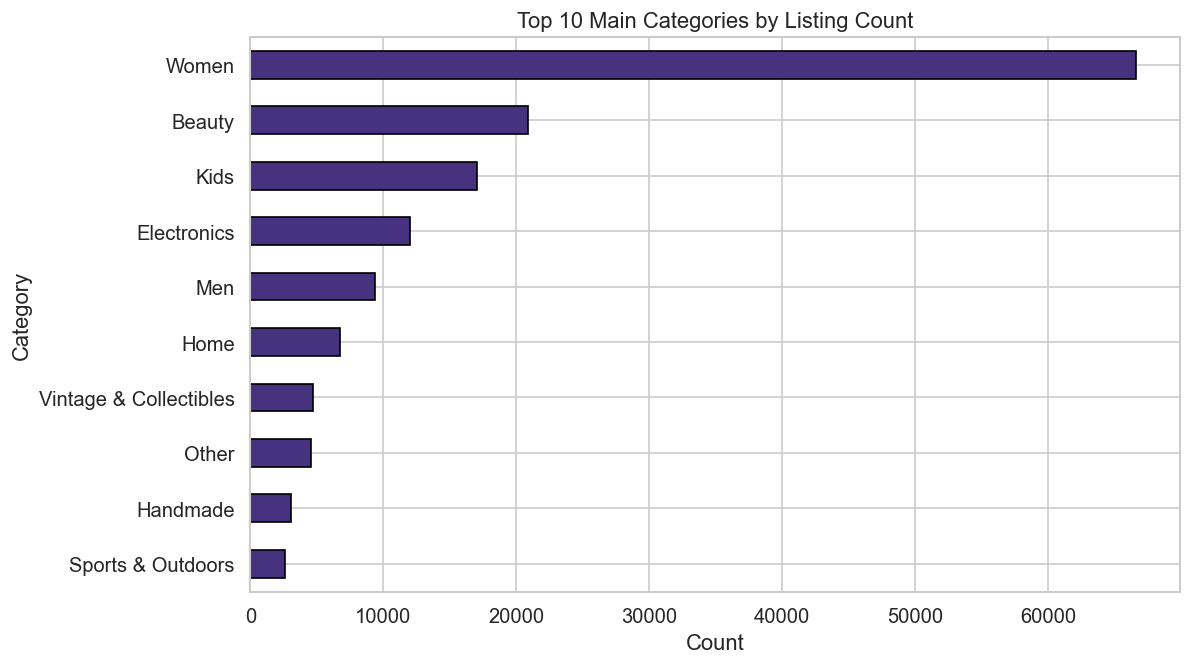

In [20]:
df['category_main'] = df['category_name'].str.split('/').str[0]
top_10_cats = df['category_main'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_10_cats.sort_values().plot(kind='barh', edgecolor='k')
plt.title('Top 10 Main Categories by Listing Count')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

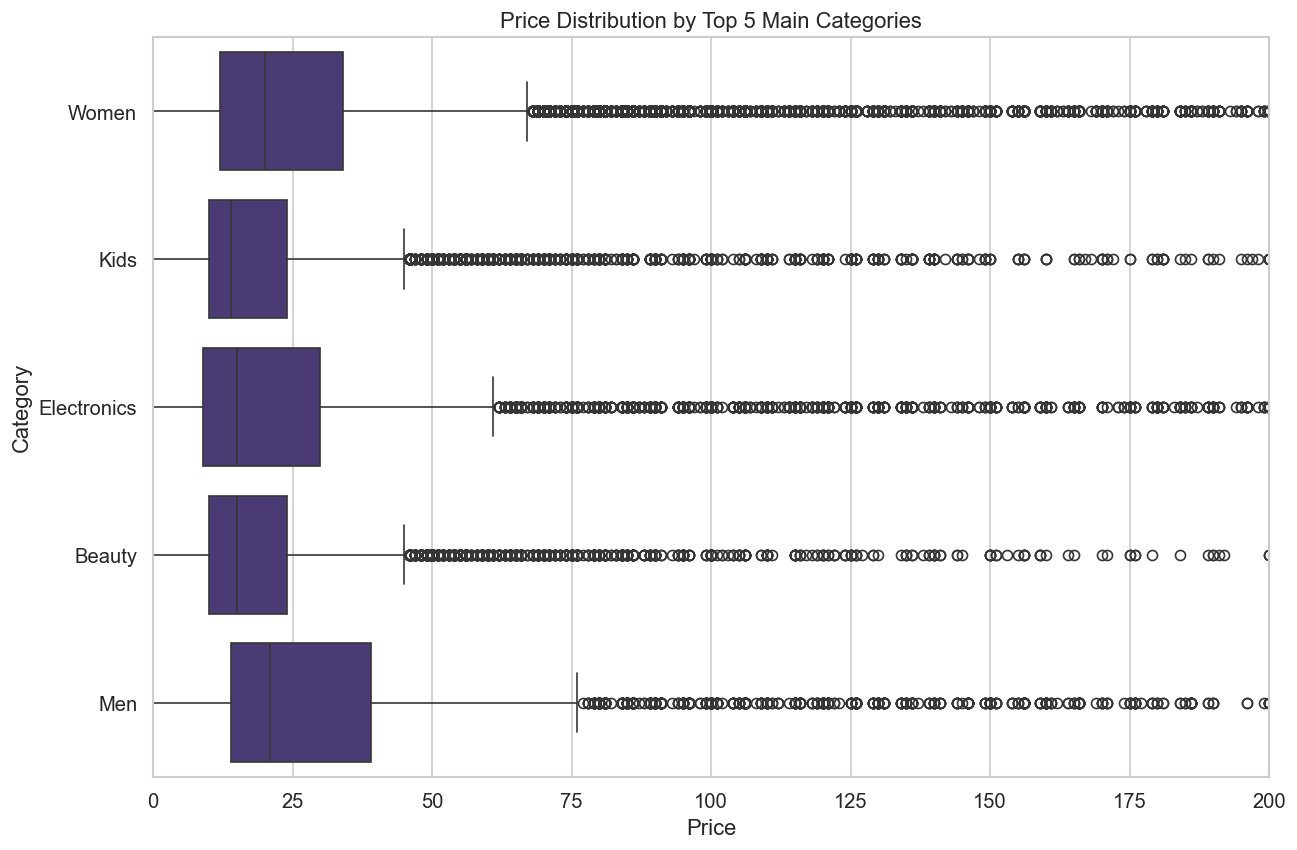

In [21]:
top_5_cats = df['category_main'].value_counts().head(5).index
df_top_5 = df[df['category_main'].isin(top_5_cats)]

plt.figure(figsize=(12, 8))
sns.boxplot(data=df_top_5, x='price', y='category_main')
plt.title('Price Distribution by Top 5 Main Categories')
plt.xlabel('Price')
plt.ylabel('Category')
plt.xlim(0, 200) # Limit x-axis to avoid extreme outliers skewing the plot
plt.show()

In [22]:
missing_stats = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_stats = missing_stats[missing_stats['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
missing_stats

,Missing Count,Missing Percentage
brand_name,62991,42.488854
category_name,641,0.432369
category_main,641,0.432369


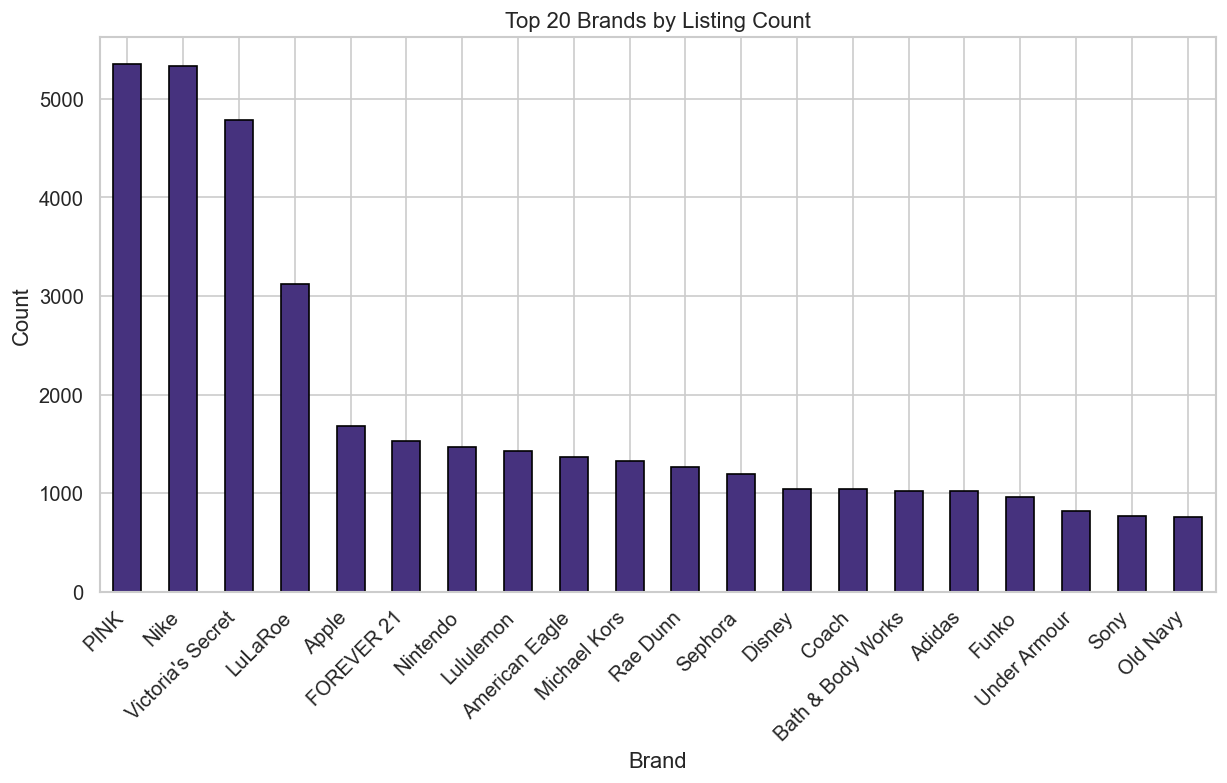

In [23]:
top_20_brands = df['brand_name'].value_counts().head(20)

plt.figure(figsize=(12, 6))
top_20_brands.plot(kind='bar', edgecolor='k')
plt.title('Top 20 Brands by Listing Count')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()

In [24]:
df.describe()

,train_id,item_condition_id,price,shipping
count,148253.000000,148253.000000,148253.000000,148253.000000
mean,74126.000000,1.904164,26.807933,0.446413
std,42797.099066,0.901663,39.358186,0.497122
min,0.000000,1.000000,0.000000,0.000000
25%,37063.000000,1.000000,10.000000,0.000000
50%,74126.000000,2.000000,17.000000,0.000000
75%,111189.000000,3.000000,29.000000,1.000000
max,148252.000000,5.000000,2000.000000,1.000000
